# Simulate unevenly spaced seasonal time series data
[source](https://towardsdatascience.com/step-by-step-guide-to-creating-simulated-data-in-python-0845e13e297c/)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from datetime import date, timedelta

def create_time_series(
    start_date,
    magnitude=10.0,
    log_rate=1.0,
    seasonal_cycles={},
    seed=None,
    y_label="y",
    plot=False,
):
    """
    Creates a time series dataset with a seasonal component.

    Parameters
    ----------
    start_date : str or datetime-like
        The starting date for the time series (data runs until today).
    magnitude : float
        Scales the amplitude of the entire signal.
    log_rate : float
        Average number of readings per day.
    seasonal_cycles : dict or None
        Dict of {period_in_days: amplitude}, e.g. {7: 0.5, 365.25: 1.0}
    seed : int or None
        Random seed for reproducibility (None means no seed is set).
    y_label : str, optional
        Column name for the value column in the returned DataFrame (default: "y").
    plot : bool, optional
        If True, displays a matplotlib plot of the time series (default: False).

    Returns
    -------
    pl.DataFrame
        A DataFrame with columns ["time", y_label], where "time" contains
        date values and y_label contains the simulated values.
        Only one entry per day is returned (mean of any same-day values, rounded).
    """
    rng = np.random.default_rng(seed)
    start = date.fromisoformat(str(start_date)) if not isinstance(start_date, date) else start_date

    def seasonal_component(t, cycles):
        return sum((a * np.sin(2 * np.pi * t / p) for p, a in cycles.items()), np.zeros(len(t)))

    duration_days = (date.today() - start).days

    actual_samples = min(rng.poisson(log_rate * duration_days), duration_days)
    time_numeric = np.sort(rng.uniform(0, duration_days, actual_samples))

    # Build date list by flooring each offset to whole days
    time = [start + timedelta(days=int(t)) for t in time_numeric]

    seasonal = seasonal_component(time_numeric, seasonal_cycles)
    noise = rng.standard_normal(actual_samples)
    y = np.clip((seasonal + noise) * magnitude, 0, None).round().astype(int)

    df = (
        pl.DataFrame({"time": time, y_label: y})
        .filter(pl.col(y_label) > 0)
        .group_by("time")
        .agg(pl.col(y_label).mean().round().cast(pl.Int64))
        .sort("time")
    )

    if plot:
        time_vals = df["time"].to_list()
        y_vals = df[y_label].to_list()
        plt.figure(figsize=(10, 6))
        plt.title("Simulated Time Series Data")
        plt.xlabel("Time")
        plt.ylabel(y_label)
        plt.plot(time_vals, y_vals, "o")
        plt.tight_layout()
        plt.show()

    return df

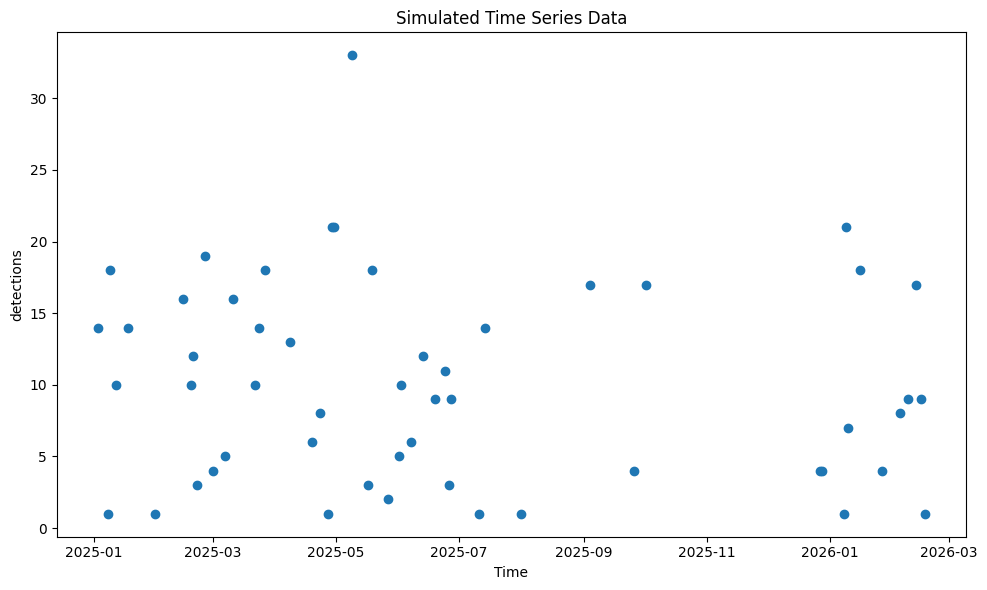

In [2]:
data = create_time_series(
    start_date="2025-01-01",
    magnitude=10.0,
    log_rate=0.3,
    seasonal_cycles={7: 0.5, 365.25: 1.0},
    y_label="detections",
    plot=True,
)